## Apartado 3. Búsqueda de hilos similares.

In [6]:
import zstandard as zstd
import json
import argparse
import io
import sys
from pathlib import Path
from datetime import datetime, UTC
import random
import os
import pandas as pd

Vamos a cargar el mismo modelo de fasttext que usamos en el apartado 2.

In [7]:
# !pip install fasttext
import fasttext
ft_model = fasttext.load_model('crawl-300d-2M-subword.bin')

In [8]:
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

rows = []
for subreddit in subreddits:
    filename = subreddit + '_final.json'

    if not os.path.exists(filename):
        print(f"No existe {filename}, se salta.")
        continue

    print(f"\nProcesando {filename}...")

    # Abrir JSON
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)  

    # Recorrer submissions
    for submission in data["submissions"]:

        # TEXTO DEL POST: juntamos título con texto del post
        texto_hilo = (submission.get("title", "") + " " + submission.get("selftext", "")).strip()

        # Añadimos ahora el texto de los comentarios del hilo
        for comment in submission.get("comments", []):
            body = comment.get("body", "").strip()

            # Guardamos el comentario si no está vacío
            if body:
                texto_hilo += body
                
        rows.append({
                    "subreddit": subreddit,
                    "texto": texto_hilo
                })
                

# Crear DataFrame
df = pd.DataFrame(rows)
df["texto"] = df["texto"].apply(lambda x: x.replace("\n", " "))


Procesando onepiece_final.json...

Procesando soccer_final.json...

Procesando gaming_final.json...

Procesando movies_final.json...

Procesando leagueoflegends_final.json...

Procesando drawing_final.json...


In [9]:
df["sentence_embeddings"] = df["texto"].apply(lambda x: ft_model.get_sentence_vector(x))
df.head()

,subreddit,texto,sentence_embeddings
0,onepiece,Official 🚨🚨🚨🚨🚨 Ace will be played by XOLODead ...,"[-0.0016739905, -0.012620177, 0.07350646, 0.00..."
1,onepiece,What is the symbol on dragon's face ? Is it a ...,"[-0.0012561227, -0.0059917225, 0.082547955, 0...."
2,onepiece,"What are exambles of ""bad devilfruits"" with go...","[-0.004081797, -0.017054116, 0.096680604, 0.01..."
3,onepiece,My Luffy live action cosplay Original sewed ve...,"[-0.0021282518, -0.025299337, 0.068572216, 0.0..."
4,onepiece,He's blonde??? Never expected for St Garling t...,"[-0.0048311288, -0.011010855, 0.086308576, 0.0..."


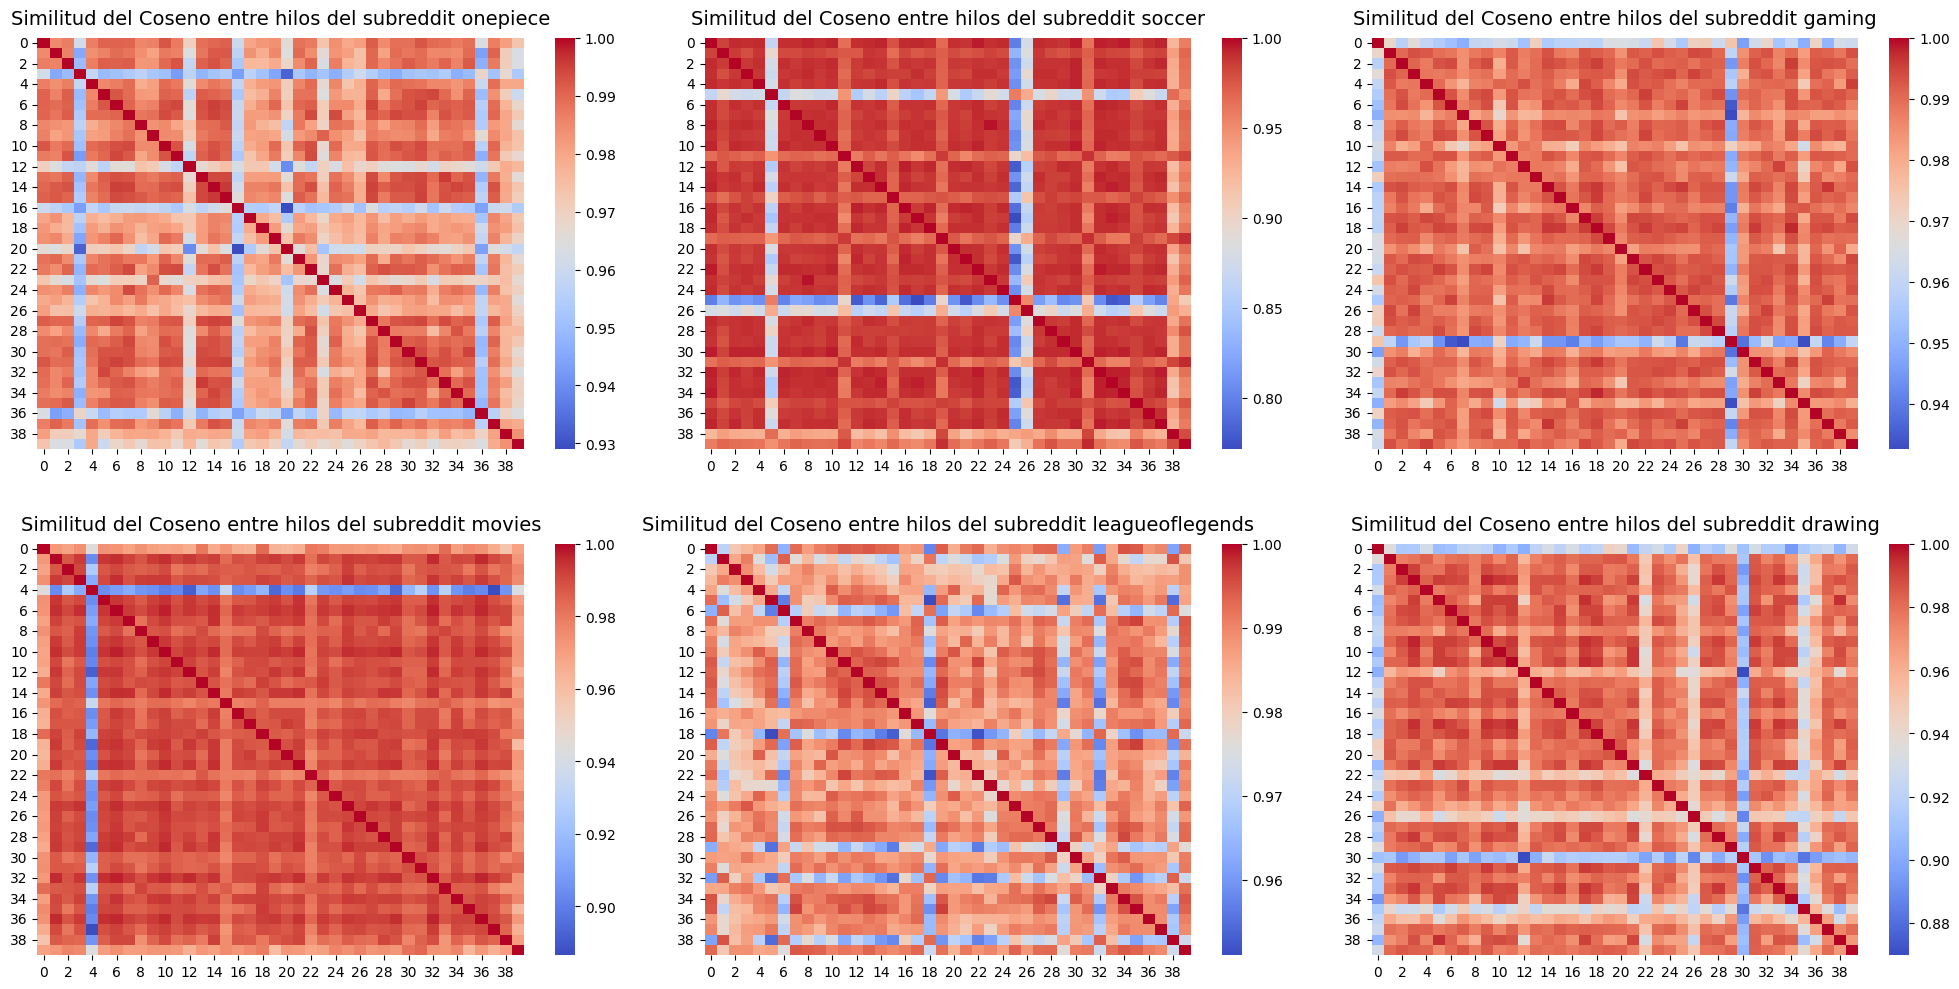

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df[df["subreddit"] == subreddit]
    # Para calcular la similaridad de los hilos, primero vamos a agrupar en una matriz de numpy todos los embeddings
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings'].values)
    # Con esta matriz, calculamos la similaridad entre los hilos
    matriz_similitud = cosine_similarity(matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True    
    )
    axes[i].set_title(f'Similitud del Coseno entre hilos del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

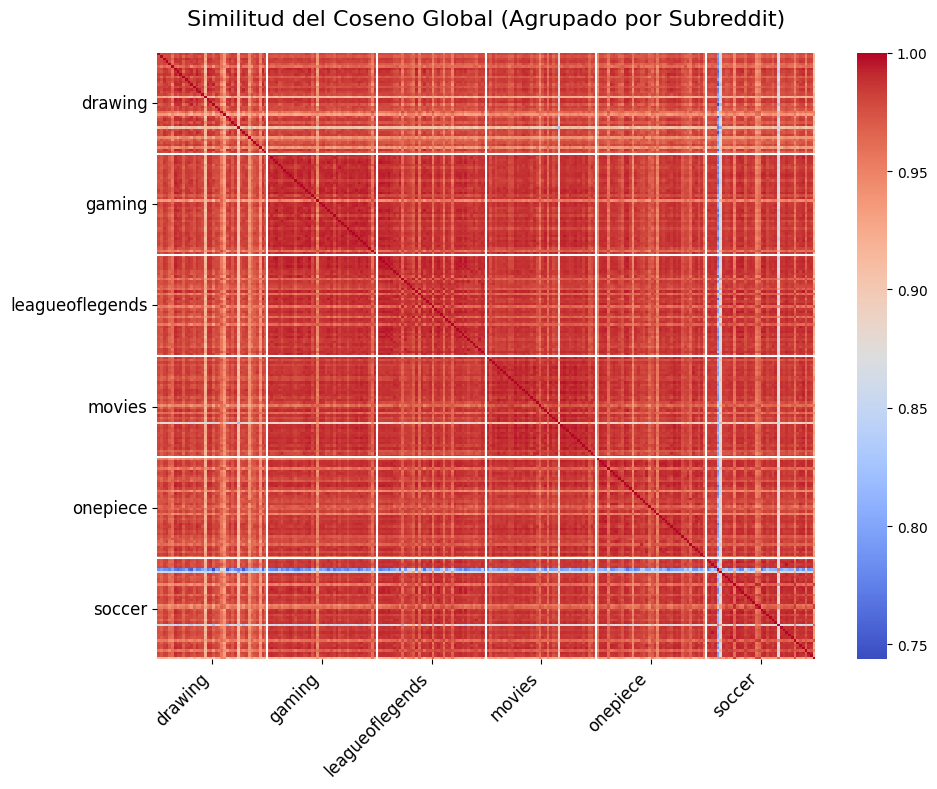

In [11]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = cosine_similarity(matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_labels = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)


plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm'
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_labels, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_labels, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

Observando el mapa de calor, vemos que praácticamente todos los hilos son muy similares entre sí, esto es lo esperado, ya que los textos no se han normalizado (eliminado las stop words, etc.). Además, cuando los hilos son muy largos, los vectores de tantas palabras tienden a mezclarse en distintas direcciones, y al promediarlos, el vector final tiende a apuntar al "centro" del idioma.

### Ahora vamos a realizar un pca para poder representar los sentence embeddings en un gráfico.

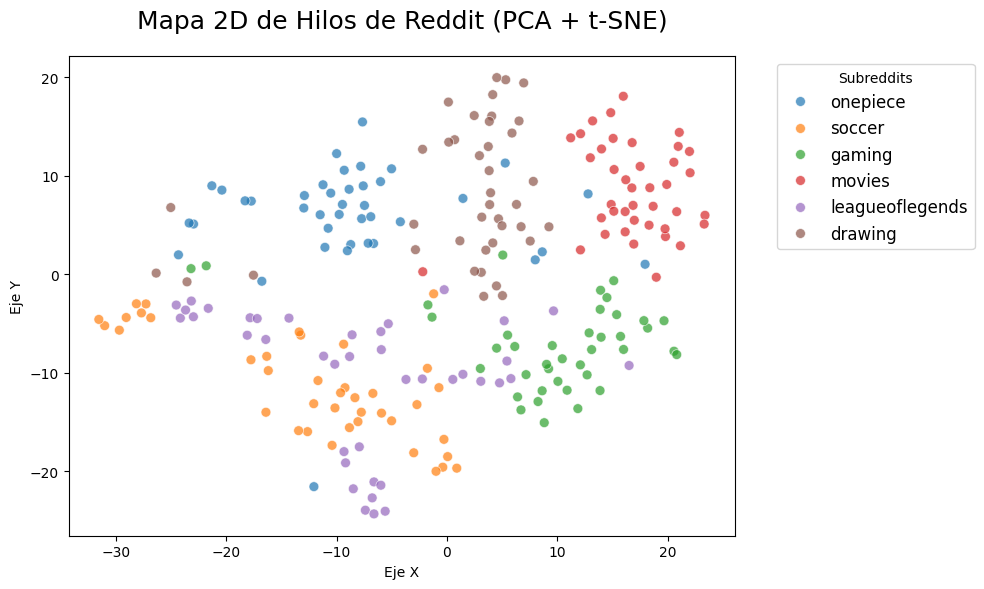

In [12]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

matriz_embeddings = np.vstack(df['sentence_embeddings'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

Viendo el gráfico resultante, los hilos de un mismo subreddit tienden a agruparse en la misma zona, sin embargo, se siguen mezclando hilos de distintos subreddits, y en algunos casos parece muy complicado de diferenciar a que subreddit pertenecen, en el centro de la gráfica hay al menos un hilo de todos los subreddits.

### Ahora vamos a normalizar el texto de los hilos y ver si con esto mejora la distintividad de los hilos.

Para esto, vamos a hacer uso de la misma función de limpieza que en el apartado 2.

In [13]:
import nltk
!pip install demoji
import demoji
import re
from nltk.corpus import stopwords

# Descargar recursos necesarios
nltk.download('stopwords')

# Stopwords en inglés
stop_words = set(stopwords.words('english'))

# Añadimos algunas palabras que son muy comunes en Reddit y no aportan mucho
stop_words.update(['edit', 'thanks', 'post', 'reddit'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\30mmn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# Función de limpieza

def limpiar_texto(texto):

    # Eliminamos URLs
    texto = re.sub(r'http\S+|www\S+', ' ', texto)

    # Elimiamos emojis
    texto = demoji.replace(texto, "")
    
    # Eliminar menciones de Reddit tipo u/usuario o /u/usuario
    texto = re.sub(r'/?u\/\w+', ' ', texto)

    # Eliminar menciones tipo @usuario
    texto = re.sub(r'@\w+', ' ', texto)
    
    # Quitamos saltos de línea
    texto = texto.replace("\n", " ")

    # Separamos por espacios
    palabras = texto.split()

    # Quitamos las stopwords
    palabras_limpias = [p for p in palabras if p.lower() not in stop_words]

    # Volvemos a unir las palabras del texto en un string
    texto = " ".join(palabras_limpias)

    return texto

In [15]:
df["texto_clean"] = df["texto"].apply(lambda x: limpiar_texto(x))
df["sentence_embeddings_norm"] = df["texto_clean"].apply(lambda x: ft_model.get_sentence_vector(x))
df.head()

,subreddit,texto,sentence_embeddings,texto_clean,sentence_embeddings_norm
0,onepiece,Official 🚨🚨🚨🚨🚨 Ace will be played by XOLODead ...,"[-0.0016739905, -0.012620177, 0.07350646, 0.00...",Official Ace played XOLODead man walking.He be...,"[-0.00730918, -0.014850558, 0.06812135, 0.0021..."
1,onepiece,What is the symbol on dragon's face ? Is it a ...,"[-0.0012561227, -0.0059917225, 0.082547955, 0....",symbol dragon's face ? scar ? tattoo ? birthma...,"[-0.0075778267, -0.0059806216, 0.07478378, 0.0..."
2,onepiece,"What are exambles of ""bad devilfruits"" with go...","[-0.004081797, -0.017054116, 0.096680604, 0.01...","exambles ""bad devilfruits"" good users? Doflami...","[-0.010772706, -0.025095213, 0.08495754, 0.010..."
3,onepiece,My Luffy live action cosplay Original sewed ve...,"[-0.0021282518, -0.025299337, 0.068572216, 0.0...",Luffy live action cosplay Original sewed vest ...,"[-0.00669126, -0.030482812, 0.061244432, 0.011..."
4,onepiece,He's blonde??? Never expected for St Garling t...,"[-0.0048311288, -0.011010855, 0.086308576, 0.0...",blonde??? Never expected St Garling blonde. ac...,"[-0.012190034, -0.014664516, 0.07330867, 0.012..."


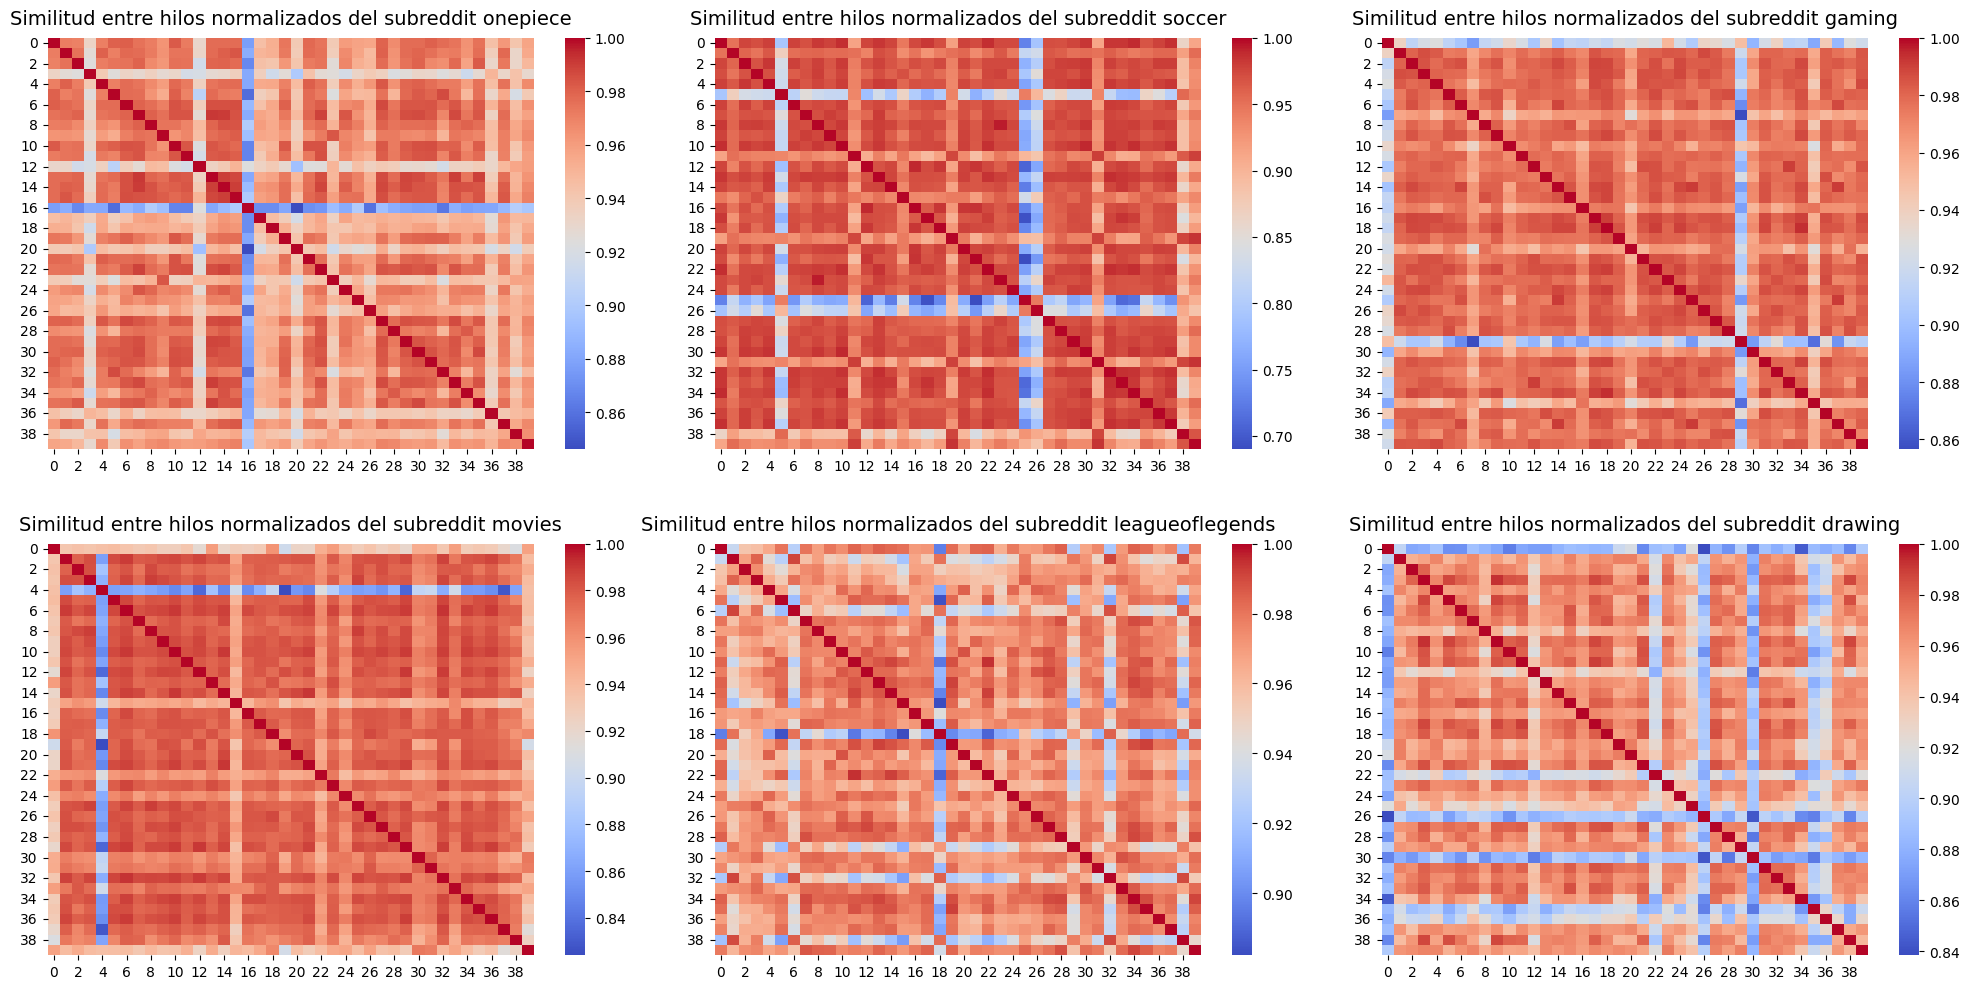

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df[df["subreddit"] == subreddit]
    # Para calcular la similaridad de los hilos, primero vamos a agrupar en una matriz de numpy todos los embeddings
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings_norm'].values)
    # Con esta matriz, calculamos la similaridad entre los hilos
    matriz_similitud = cosine_similarity(matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True      
    )
    axes[i].set_title(f'Similitud entre hilos normalizados del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

Al normalizar, vemos como la similitud entre los hilos de un mismo subreddit ha disminuido un poco, aunque siguen siendo muy similares entre sí (en todos los subreddits, excepto en el de fútbol, la similaridad mínima es de un 84%).

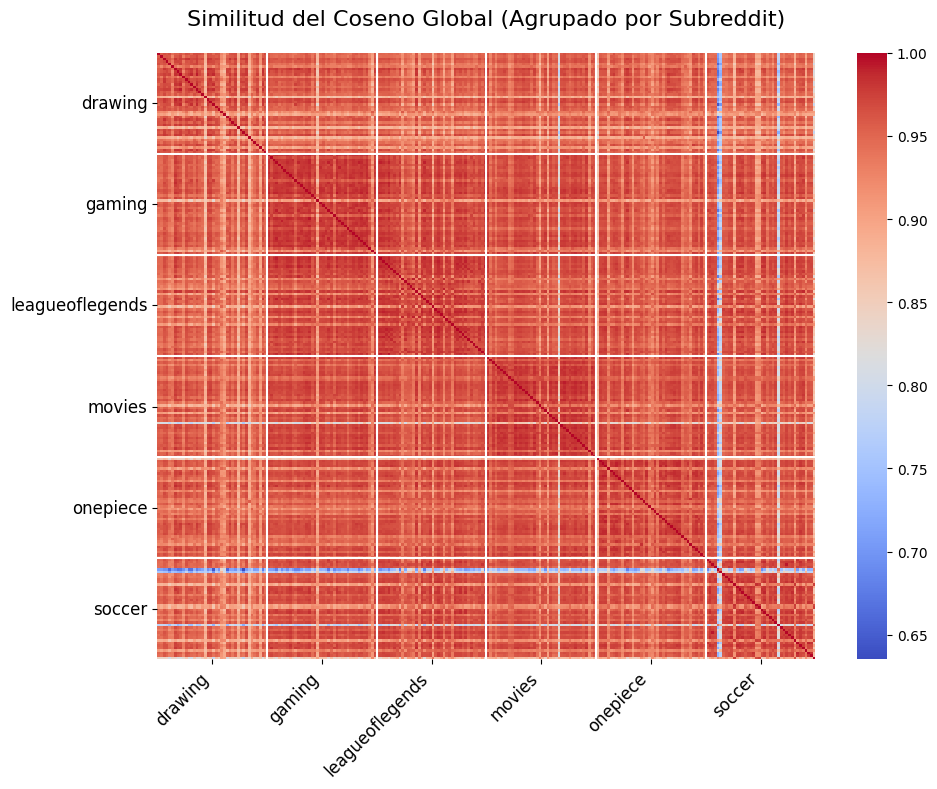

In [17]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings_norm'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = cosine_similarity(matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_labels = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)


plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm'
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_labels, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_labels, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

Como vemos, aunque la similaridad general se ha reducido un poco (son rojos más claritos), todavía siguen siendo muy similares todos los hilos entre sí, por lo que con la normalización del texto no se aprecia mucha mejora, por lo menos en el mapa de calor. Aunque se hayan eliminado las stop words, sigue habiendo el mismo problema de que se produce un efecto "sopa".

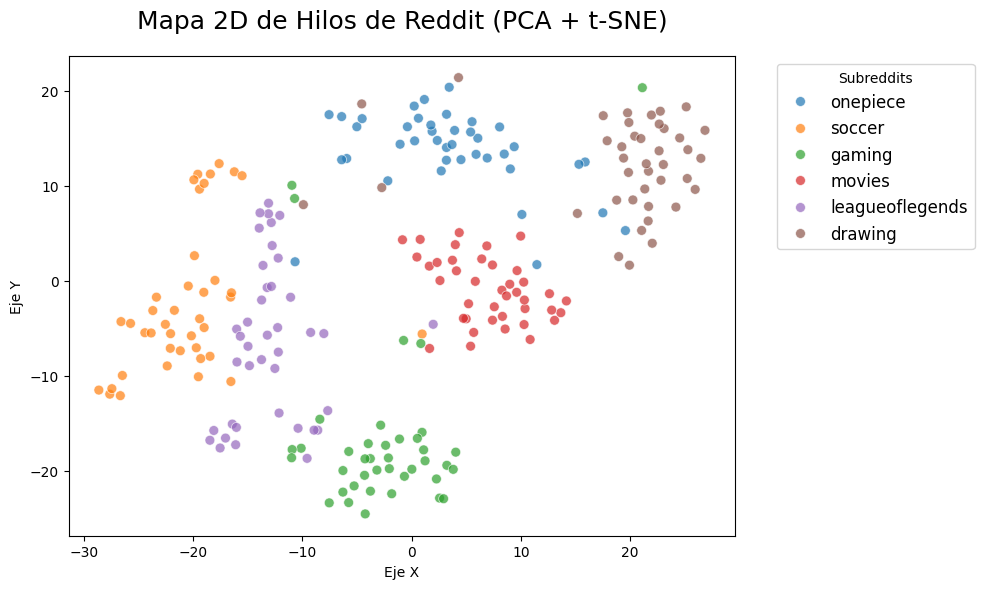

In [18]:
matriz_embeddings = np.vstack(df['sentence_embeddings_norm'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

Viendo la gráfica con el texto de los hilos normalizado, ahora si que se aprecia claramente como los hilos de cada subreddit se agrupan en zonas distintas y hay poca mezcla de hilos de varios subreddits. Por lo que la normalización en este caso, si ha supuesto una mejora importante a la hora de discernir los distintos subreddits.

## Tarea adicional. Usar modelos sentence-transformers.

El primero modelo que usaremos será **sentence-transformers/all-MiniLM-L6-v2**

In [19]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
# Primero haremos una copia del dataframe con las columnas con el texto
df_transformer = df[["subreddit", "texto", "texto_clean"]].copy()
texto_hilos = df_transformer["texto"].tolist()
# Creamos los sentence embeddings y los guardamos en el nuevo dataframe
embeddings = model.encode(texto_hilos, show_progress_bar=True)    
df_transformer["sentence_embeddings"] = list(embeddings)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

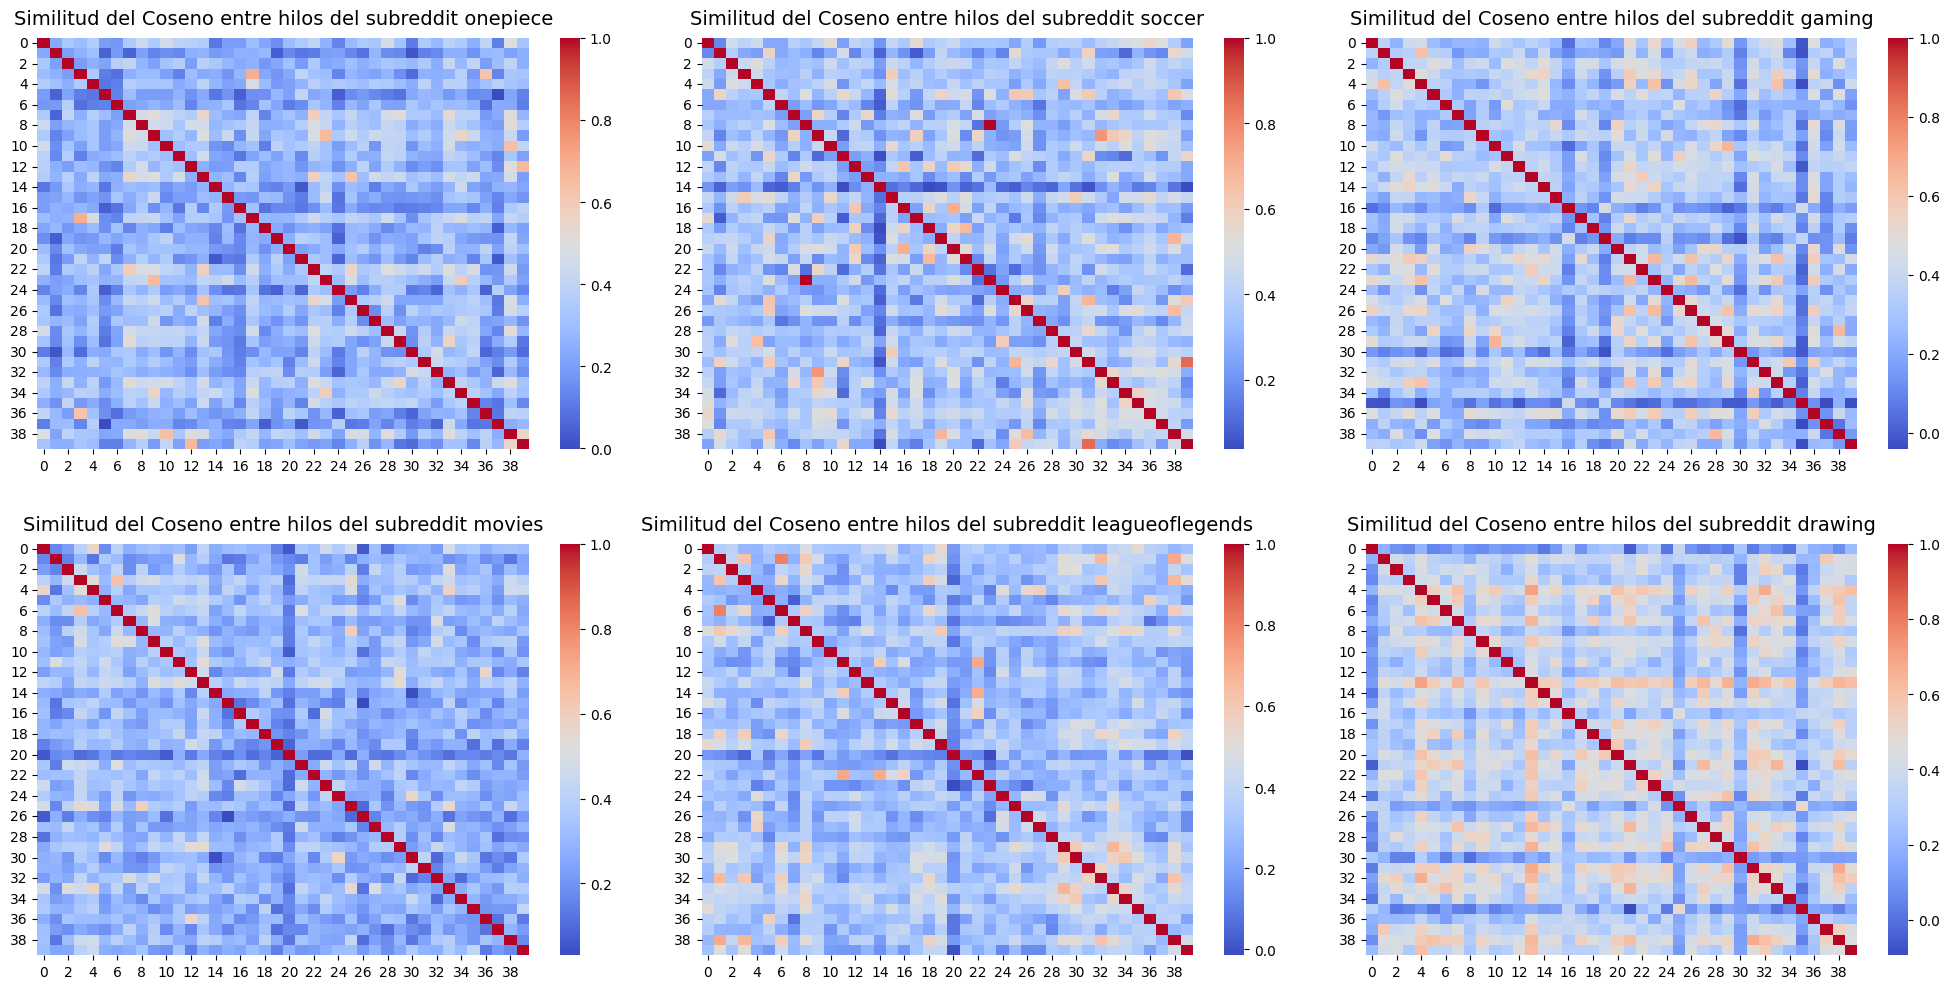

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df_transformer[df_transformer["subreddit"] == subreddit]
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings'].values)
    matriz_similitud = model.similarity(matriz_embeddings, matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True   
    )
    axes[i].set_title(f'Similitud del Coseno entre hilos del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

Utilizando este modelo de sentence-transformer, vemos que ocurre lo contrario que utilizando el modelo de fasttext, vemos que la similaridad de un hilo con los demás es muy baja en todos los subreddits.

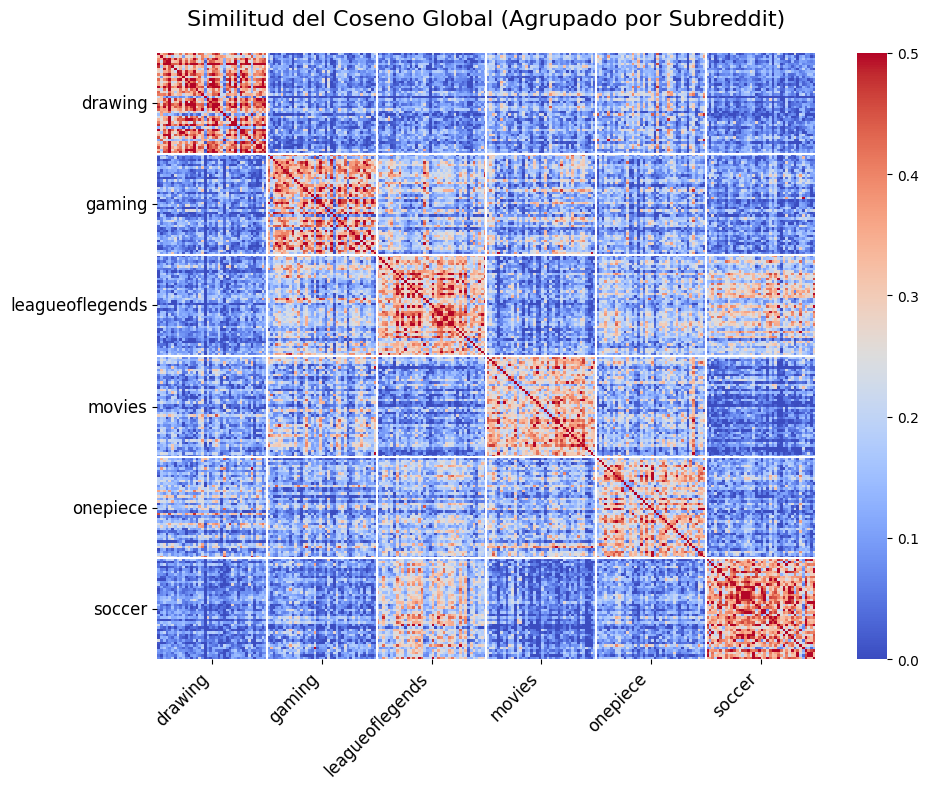

In [22]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df_transformer.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = model.similarity(matriz_embeddings, matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_labels = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)


plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm',
    vmin=0, vmax=0.5
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_labels, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_labels, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

En este mapa de calor hemos asignado el vmax (límite superior) en 0.5 para tner una mejor representación de la similaridad de los hilos, ya que como hemos visto antes, aunque fueran del mismo subreddit, los hilos eran muy distintos entre sí. Con esta configuración ahora sí que se aprecia como los hilos de un mismo subreddit tienen una similaridad mucho mayor comparada con la de hilos de otros subreddits.

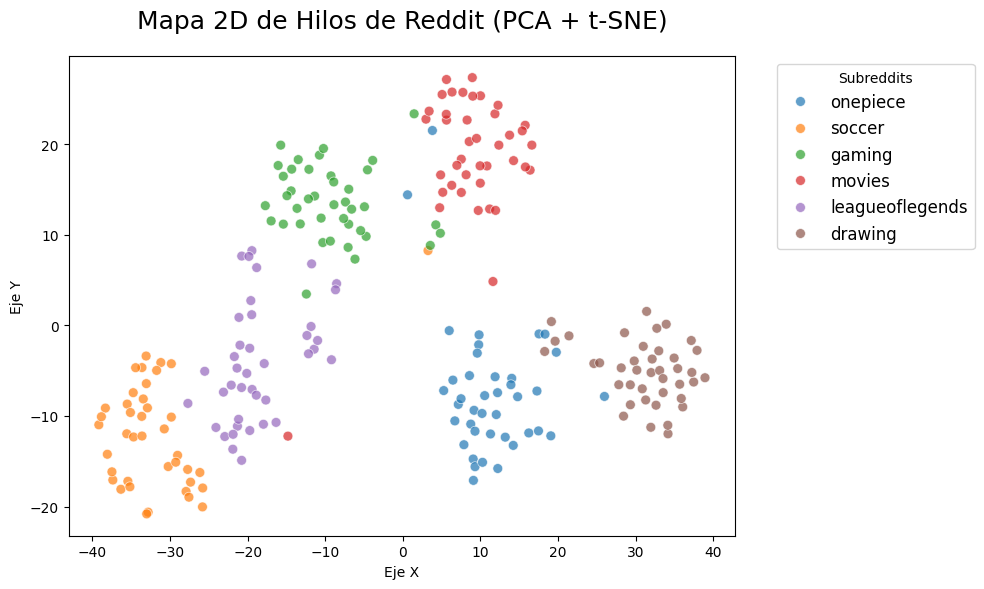

In [23]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

matriz_embeddings = np.vstack(df_transformer['sentence_embeddings'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df_transformer['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

Viendo este gráfico, los hilos de los distintos subreddits se separan mucho mejor que con el modelo sentence embeddings. También se puede observar que los embeddings de gaming y League of Legends son cercanos, lo que tiene sentido al ser League of Legends un viedojuego, cosa que no pasaba (o no era tan claro) en los demás gráficos de PCA + t-SNE, en el que incluso estaba más mezclado con el subreddit de fútbol que con el de gaming.

### Ahora, al igual que antes vamos a usar el texto normalizado para calcular la similaridad de los hilos

In [24]:
df_transformer["texto_clean"] = df_transformer["texto"].apply(lambda x: limpiar_texto(x))
texto_hilos = df_transformer["texto_clean"].tolist()
embeddings = model.encode(texto_hilos, show_progress_bar=True)    
df_transformer["sentence_embeddings_norm"] = list(embeddings)
df_transformer.head()

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

,subreddit,texto,texto_clean,sentence_embeddings,sentence_embeddings_norm
0,onepiece,Official 🚨🚨🚨🚨🚨 Ace will be played by XOLODead ...,Official Ace played XOLODead man walking.He be...,"[-0.17938751, -0.02221633, -0.04486143, 0.0216...","[-0.13562404, -0.044887602, -0.053736143, -0.0..."
1,onepiece,What is the symbol on dragon's face ? Is it a ...,symbol dragon's face ? scar ? tattoo ? birthma...,"[-0.055683415, 0.075779065, 0.015589935, 0.066...","[-0.06353743, 0.037729412, 0.05242287, 0.04033..."
2,onepiece,"What are exambles of ""bad devilfruits"" with go...","exambles ""bad devilfruits"" good users? Doflami...","[-0.03507153, 0.06459219, -0.007830667, 0.0453...","[-0.06703406, 0.041222155, -0.013041912, 0.019..."
3,onepiece,My Luffy live action cosplay Original sewed ve...,Luffy live action cosplay Original sewed vest ...,"[-0.117009126, 0.08674514, 0.05752653, -0.0911...","[-0.1299336, 0.083374254, 0.061805237, -0.0895..."
4,onepiece,He's blonde??? Never expected for St Garling t...,blonde??? Never expected St Garling blonde. ac...,"[-0.017867852, 0.020864995, -0.0136330165, 0.0...","[-0.070690766, -0.022049563, 0.029856522, 0.01..."


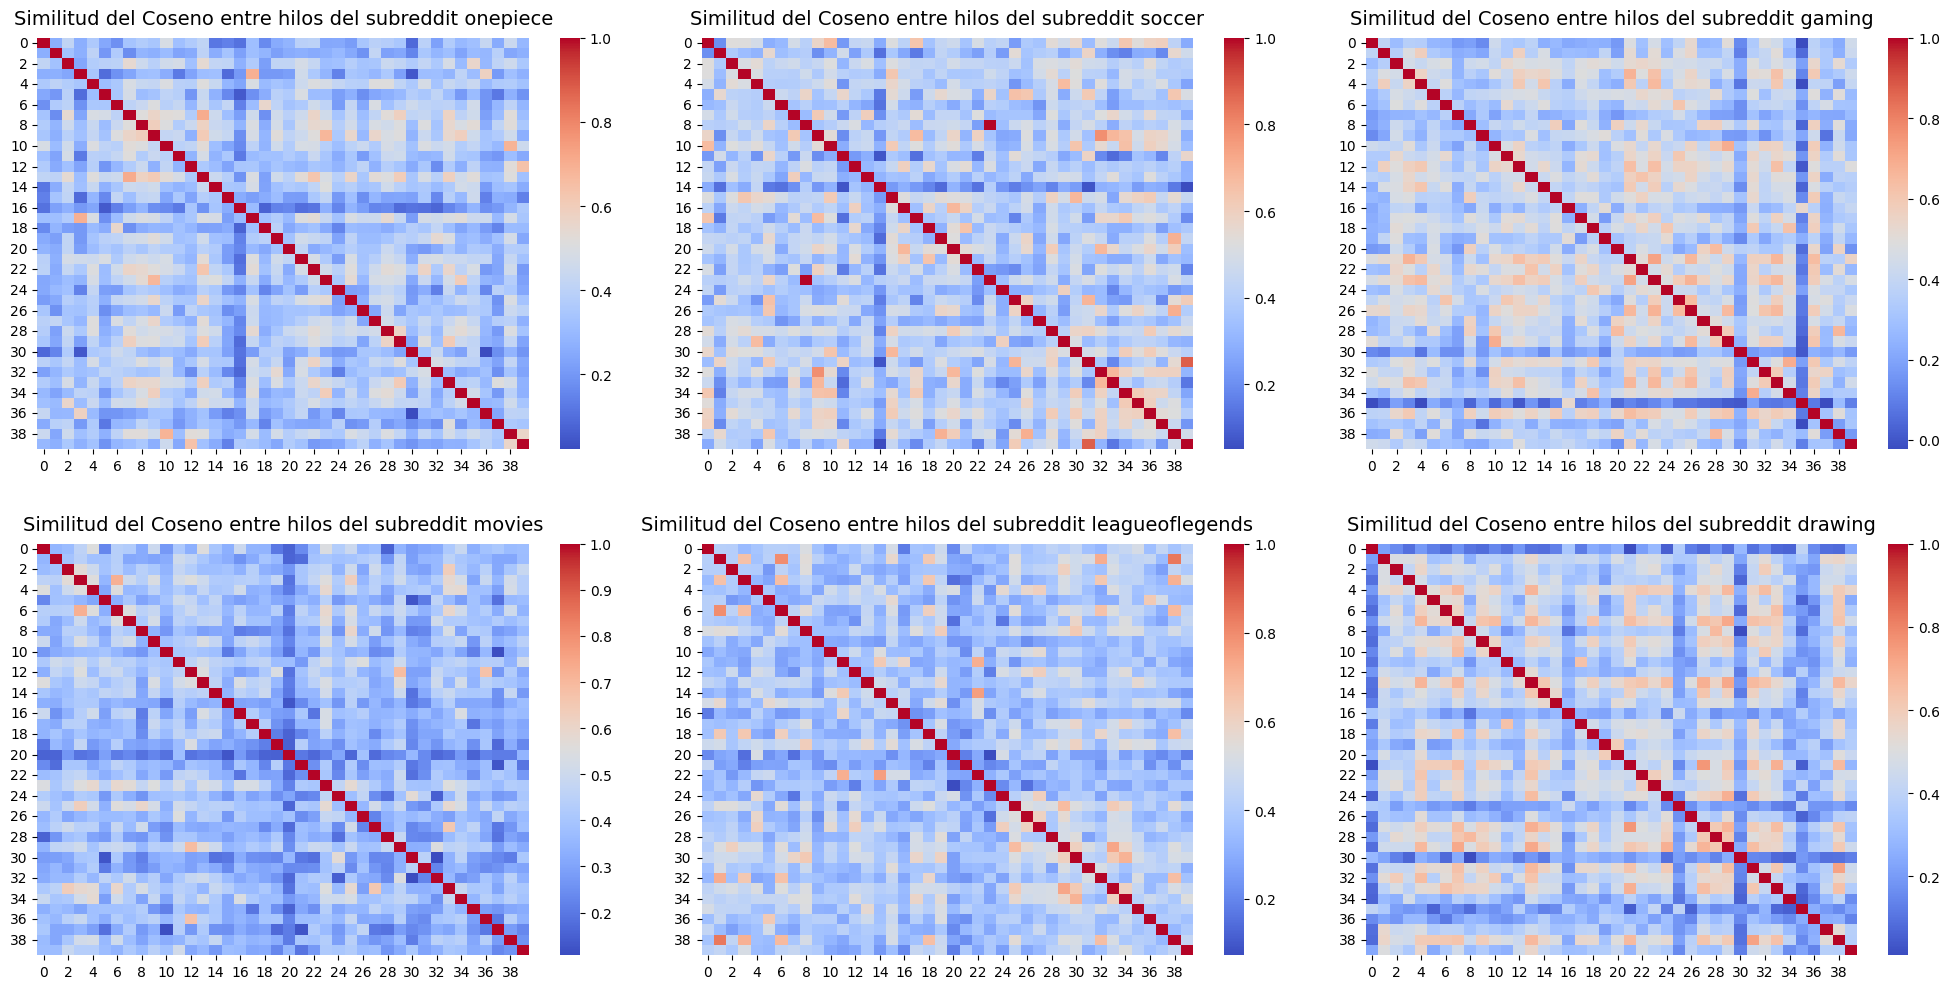

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df_transformer[df_transformer["subreddit"] == subreddit]
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings_norm'].values)
    matriz_similitud = model.similarity(matriz_embeddings, matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True   
    )
    axes[i].set_title(f'Similitud del Coseno entre hilos del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

Aun con el texto noramlizado, seguimos viendo que los hilos son muy diferentes entre sí, aunque se ha aumentado algo la similaridad dentro de los subreddits de drawing y de gaming.

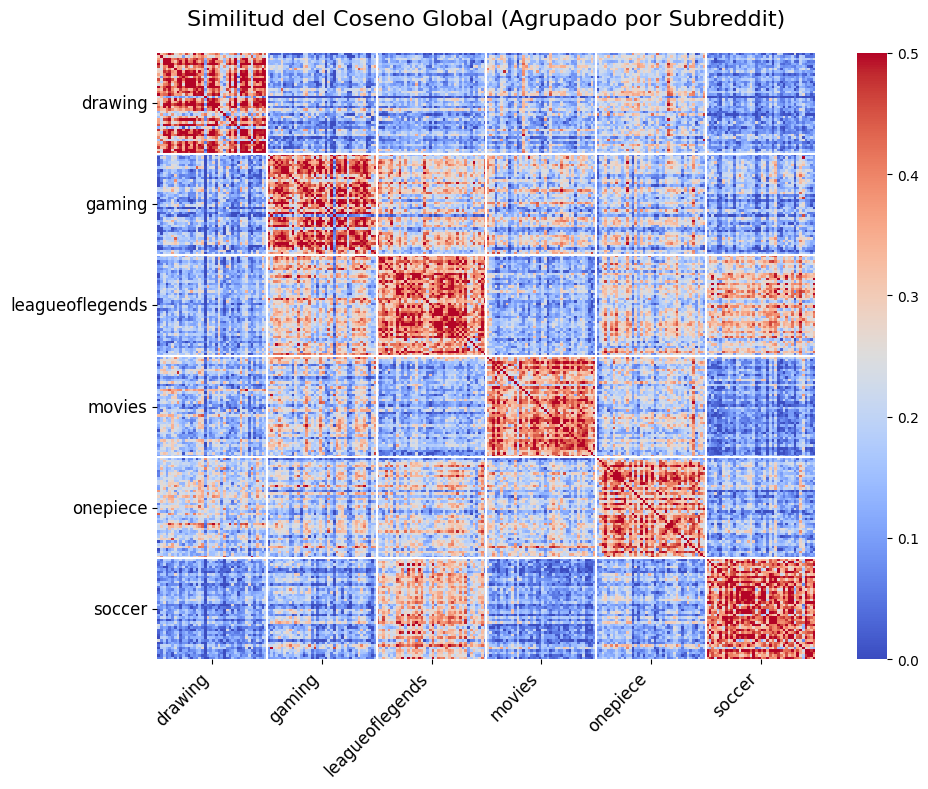

In [26]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df_transformer.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings_norm'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = model.similarity(matriz_embeddings, matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_labels = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)


plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm',
    vmin=0, vmax=0.5
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_labels, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_labels, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

Al igual que antes, seguimos usando un vmin de 0.5 para poder apreciar mejor los resultados. Con la normalización, vemos que se ha aumentado la similaridad entre los hilos de un mismo subreddit y también entre hilos de distintos subreddits. 

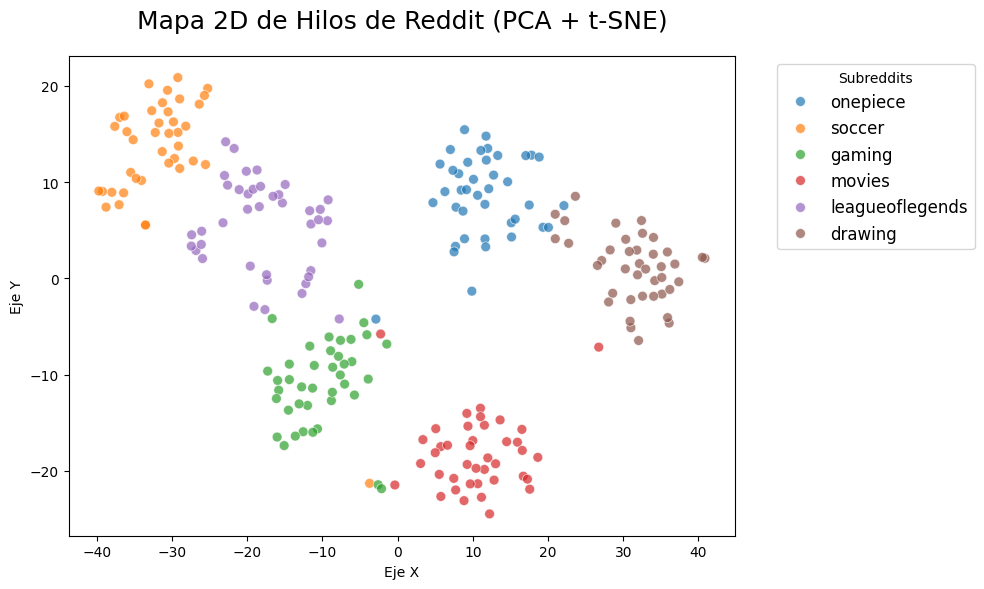

In [27]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

matriz_embeddings = np.vstack(df_transformer['sentence_embeddings_norm'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df_transformer['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

A simple viste, vemos que las agrupaciones en este gráfico son bastante separadas al igual que en el anterior. Si miramos más a fondo y cogemos este gráfico y lo volteamos verticalmente (por ejemplo usando la apliación Paint) obtenemos esta imagen: 

![alt text](image-4.png)

Vemos que la agrupación es prácticamente idéntica, esto tiene sentido, ya que en PCA se obtienen los autovectores, y si *v* es un autovector *-v* también es la misma solución. El hecho de que sean muy parecidos ambos gráficos significa que el modelo de sentence-transformer es muy robusto frente al ruido, al normalizar hemos quitado menciones y emojis y la agrupación sigue siendo similar, lo que significa que los mecanismos de **Autoatención** del modelo les daba poca importancia a estos elementos desde un principio.

### Ahora vamos a usar otro modelo de sentence-transformer y ver si funciona mejor que el que hemos usado.
El modelo que usaremos ahora será **sentence-transformers/all-mpnet-base-v2**.

In [50]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [51]:
# Primero eliminamos las columnas que contienen los embeddings del modelo anterior.
# Se podría hacer sobreescribiendo las columnas ya existentes también.
df_transformer = df_transformer.drop(columns=["sentence_embeddings", "sentence_embeddings_norm"])
texto_hilos = df_transformer["texto"].tolist()
# Creamos los sentence embeddings y los guardamos en el nuevo dataframe
embeddings = model.encode(texto_hilos, show_progress_bar=True)    
df_transformer["sentence_embeddings"] = list(embeddings)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

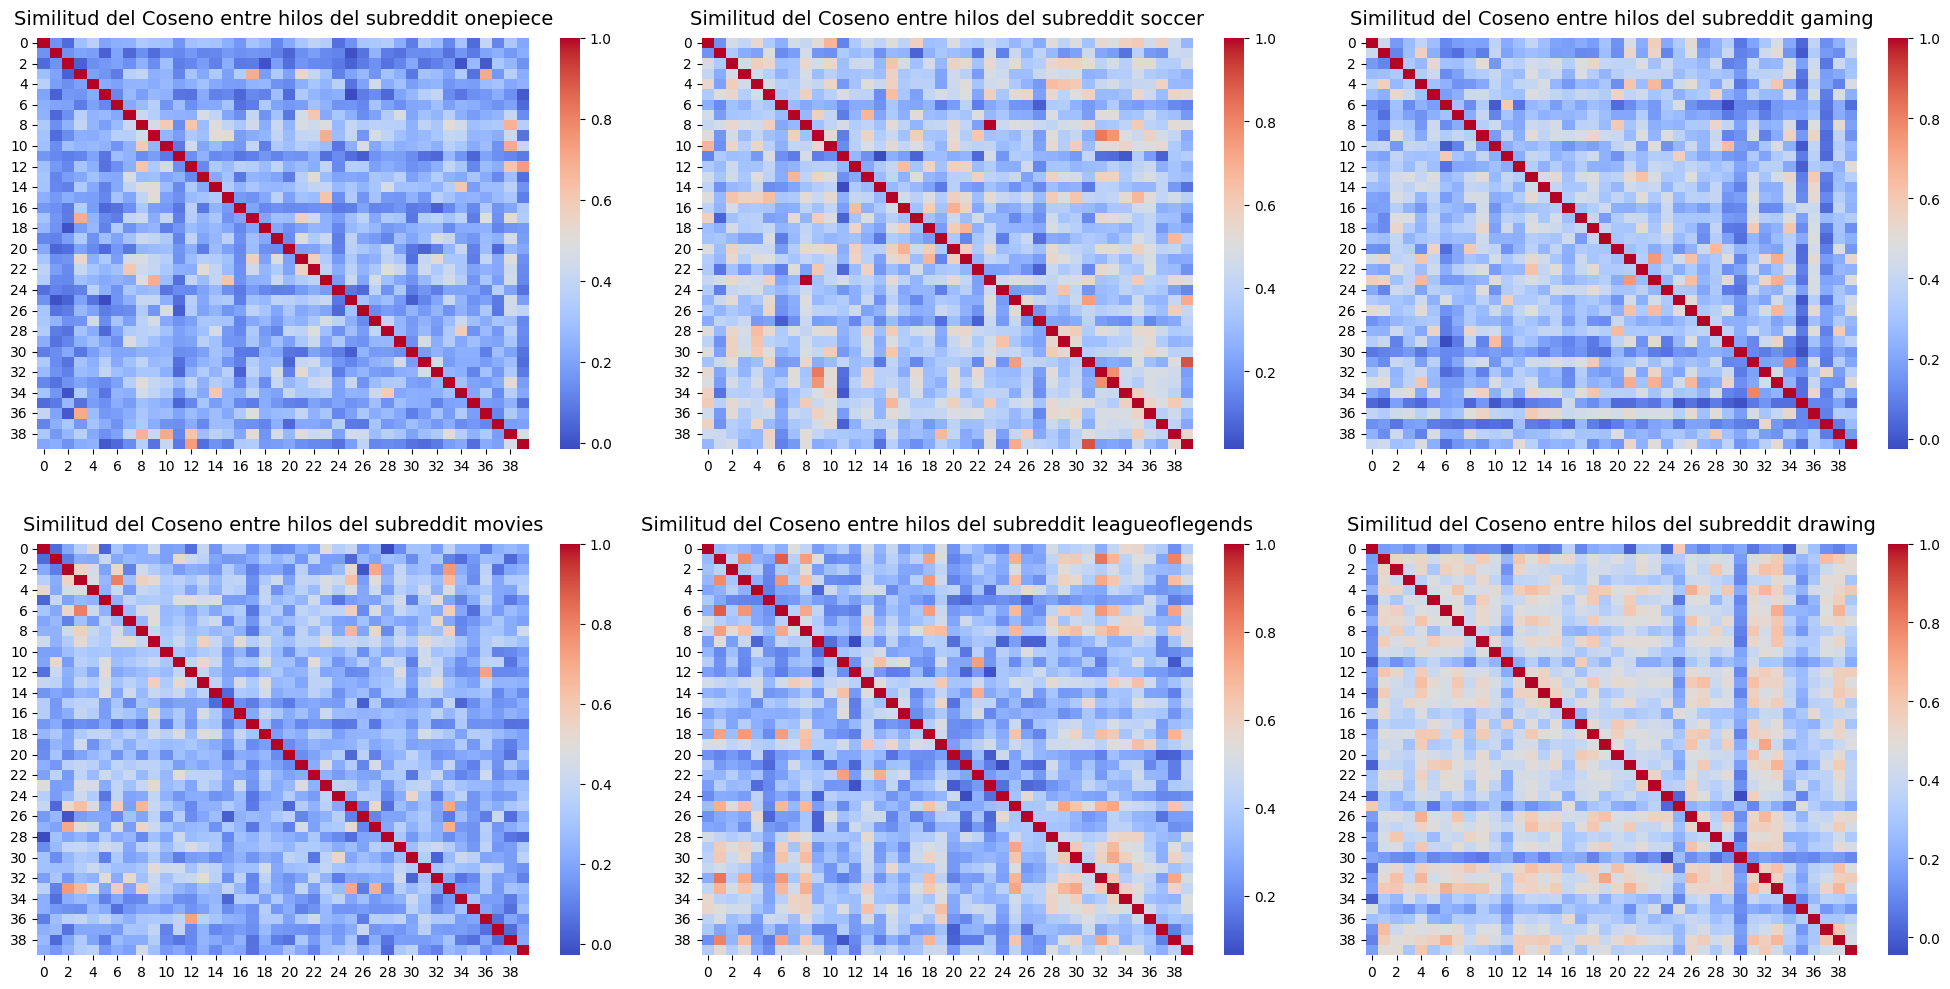

In [52]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df_transformer[df_transformer["subreddit"] == subreddit]
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings'].values)
    matriz_similitud = model.similarity(matriz_embeddings, matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True   
    )
    axes[i].set_title(f'Similitud del Coseno entre hilos del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

Los mapas de calor de los distintos subreddits, vemos que sale parecido a los del anterior modelo y siguen siendo los hilos bastante diferentes.

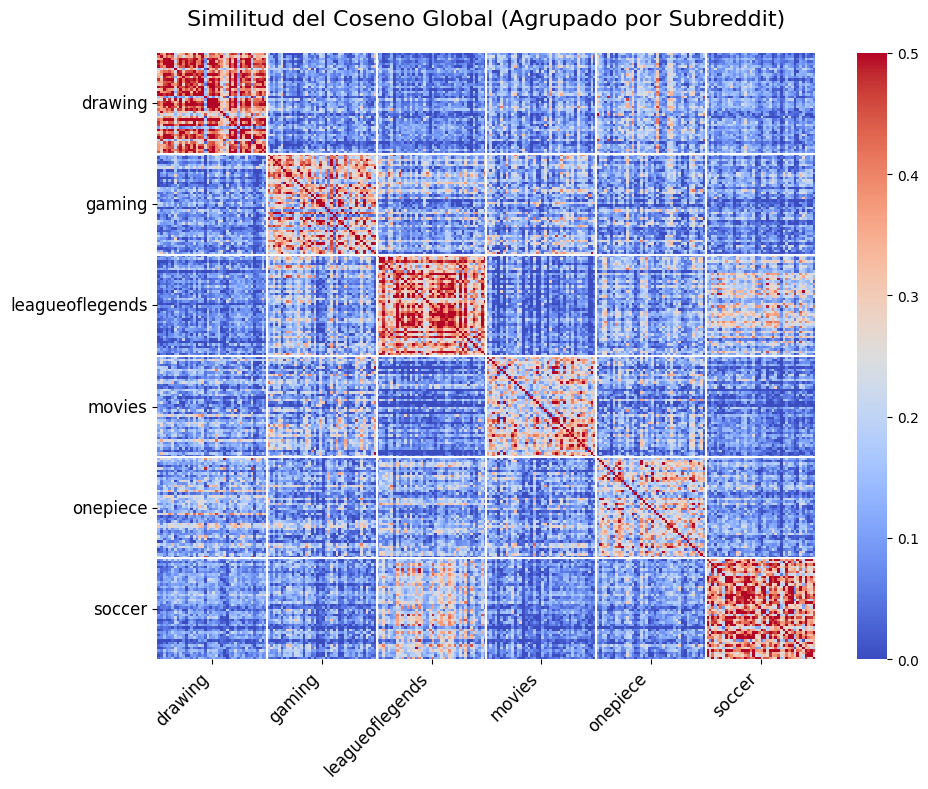

In [53]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df_transformer.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = model.similarity(matriz_embeddings, matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_labels = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)


plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm',
    vmin=0, vmax=0.5
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_labels, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_labels, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

Comparando este mapa de calor con el producido por el modelo anterior, vemos unos resultados bastante parecidos, incluso se podría decir que este modelo obtiene un resultado un poco mejor (más azul al comparar hilos de distintos subreddits que el anterior modelo).

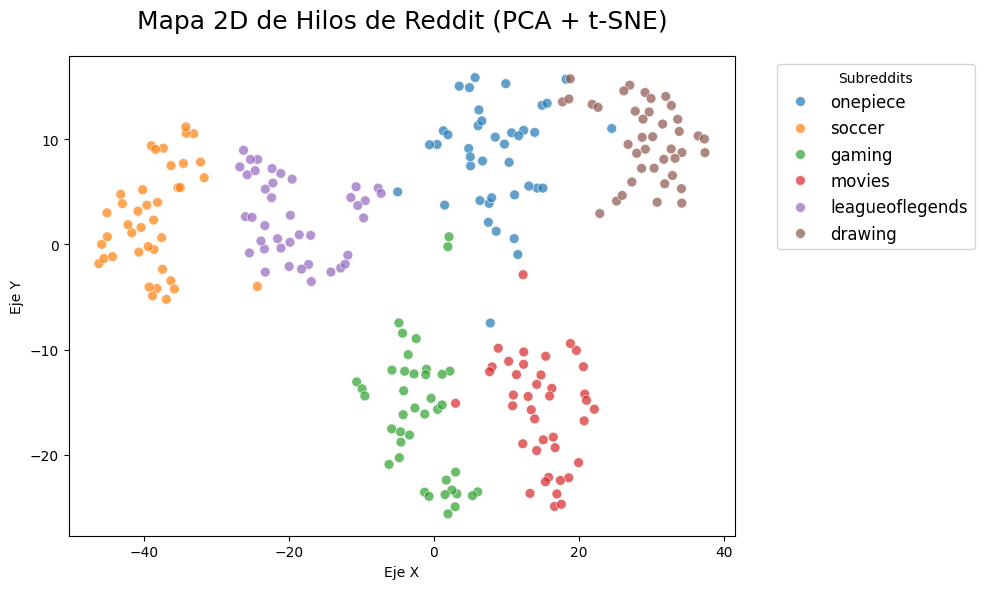

In [54]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

matriz_embeddings = np.vstack(df_transformer['sentence_embeddings'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df_transformer['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

Con este modelo también se diferencian muy bien los hilos de los distintos subreddits. En este resultado podemos apreciar que el subreddit de gaming y de League of Legends son más diferentes que con los embeddings del modelo anterior, y ahora se ve más claro que se parece más al subreddit de fútbol que al de gaming (en el anterior resultado era muy parecido a ambos).

### Calculamos la similaridad con los textos normalizados.

In [55]:
df_transformer["texto_clean"] = df_transformer["texto"].apply(lambda x: limpiar_texto(x))
texto_hilos = df_transformer["texto_clean"].tolist()
embeddings = model.encode(texto_hilos, show_progress_bar=True)    
df_transformer["sentence_embeddings_norm"] = list(embeddings)
df_transformer.head()

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

,subreddit,texto,texto_clean,sentence_embeddings,sentence_embeddings_norm
0,onepiece,Official 🚨🚨🚨🚨🚨 Ace will be played by XOLODead ...,Official Ace played XOLODead man walking.He be...,"[0.06114118, 0.020916436, 0.021373564, -0.0095...","[0.05227532, 0.019134397, 0.020065373, -0.0198..."
1,onepiece,What is the symbol on dragon's face ? Is it a ...,symbol dragon's face ? scar ? tattoo ? birthma...,"[0.040587325, 0.019254768, -0.026563732, 0.027...","[0.038975585, 0.045260474, -0.013697536, 0.039..."
2,onepiece,"What are exambles of ""bad devilfruits"" with go...","exambles ""bad devilfruits"" good users? Doflami...","[0.015708853, 0.04450324, -0.007991682, 0.0311...","[0.040439904, 0.05357841, -0.014582316, 0.0264..."
3,onepiece,My Luffy live action cosplay Original sewed ve...,Luffy live action cosplay Original sewed vest ...,"[0.052968536, 0.0054878546, 0.039501373, 0.049...","[0.017397463, 0.0056435545, 0.043796673, 0.037..."
4,onepiece,He's blonde??? Never expected for St Garling t...,blonde??? Never expected St Garling blonde. ac...,"[0.012156553, 0.05045154, 0.029796256, 0.02421...","[0.045906316, 0.081302136, 0.0071615204, 0.028..."


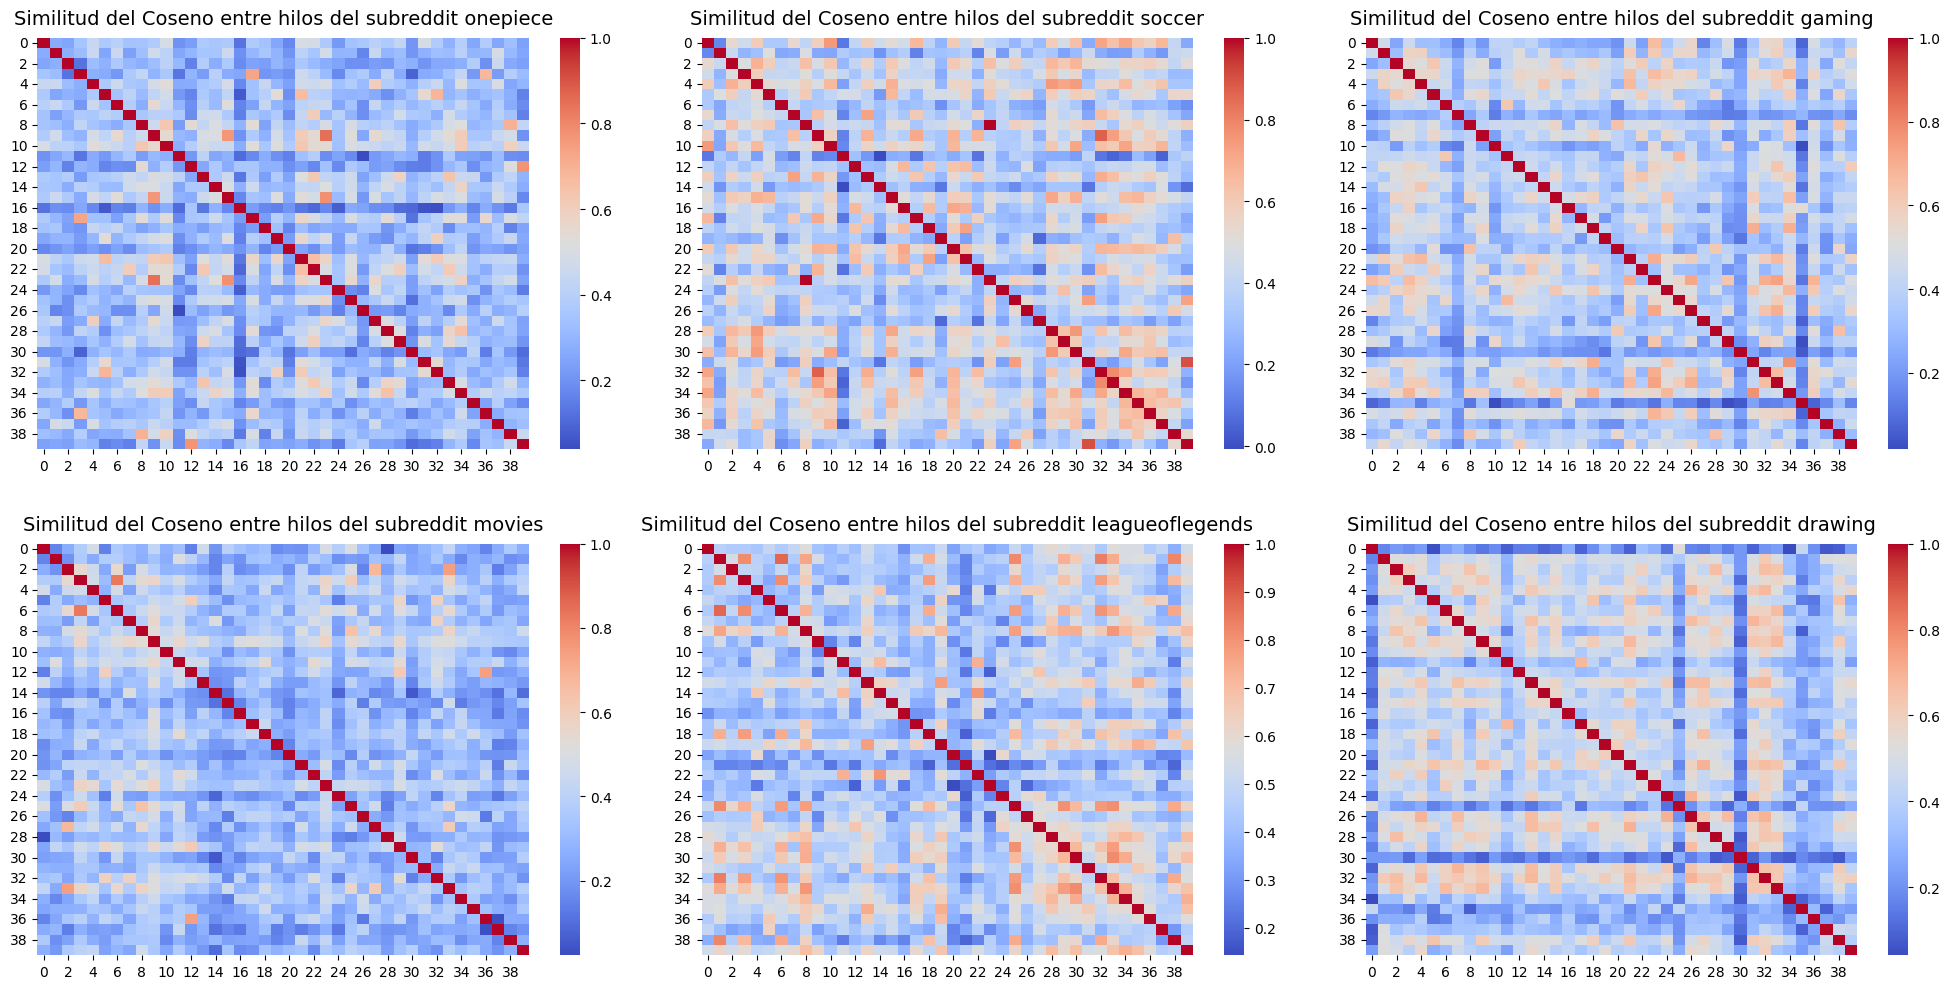

In [56]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df_transformer[df_transformer["subreddit"] == subreddit]
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings_norm'].values)
    matriz_similitud = model.similarity(matriz_embeddings, matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True   
    )
    axes[i].set_title(f'Similitud del Coseno entre hilos del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

Resultados muy similares a los anteriores.

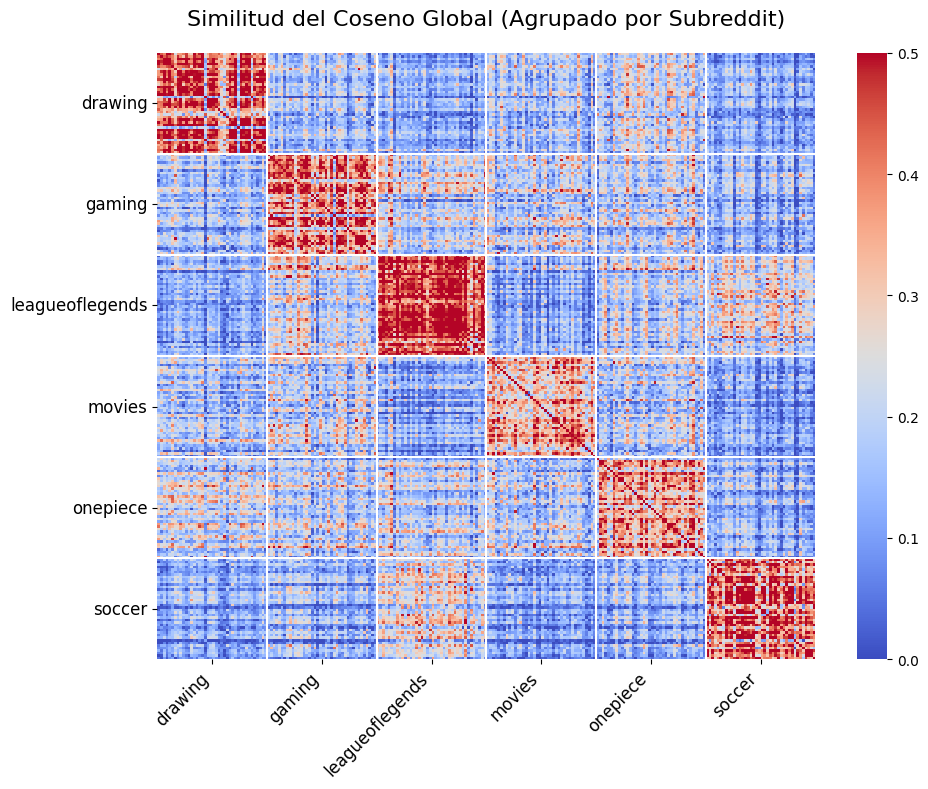

In [59]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df_transformer.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings_norm'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = model.similarity(matriz_embeddings, matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_labels = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)


plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm',
    vmin=0, vmax=0.5
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_labels, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_labels, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

Esta vez, con el texto normalizado si se aprecia una clara mejora de este modelo con respecto al anterior. En este mapa de calor se obtiene un color mucho más rojo para hilos del mismo subreddit que en el mismo mapa del modelo anterior. Y además, la similaridad entre hilos de distintos subreddtis es menor que con los embeddings del primer modelo. 

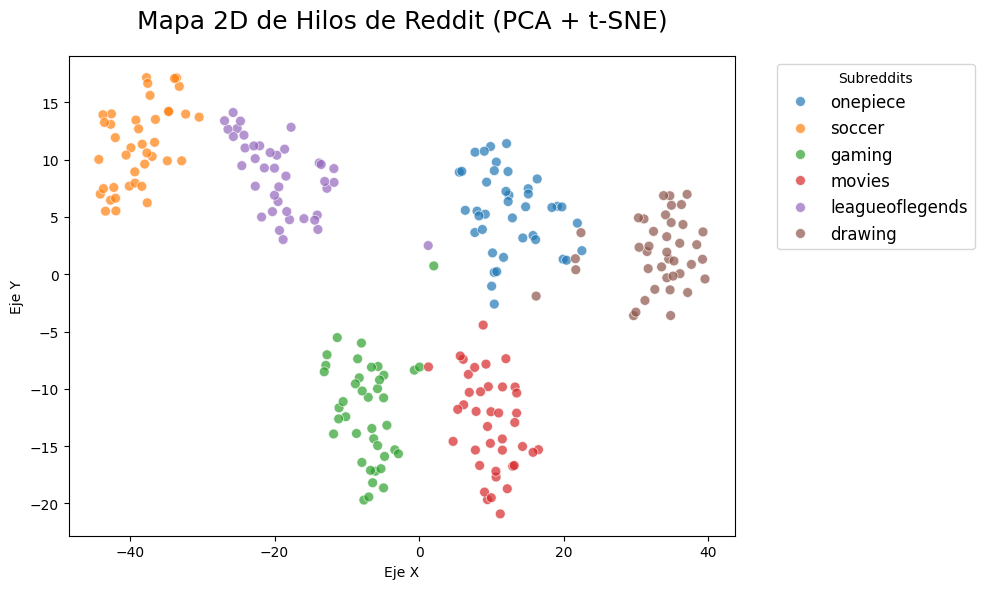

In [60]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

matriz_embeddings = np.vstack(df_transformer['sentence_embeddings_norm'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df_transformer['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

La agrupación con el texto sin normalizar ya era buena para este modelo, pero con el texto normalizado se ve una clara mejora en la diferenciación entre subreddits. Comparando este resultado con el del modelo anterior, este parece ser mejor:
- **Menos outliers:** si nos fijamos por ejemplo en el subreddit de movies (rojo) vemos que en este los embeddings de sus hilos están todos en la misma zona, mientras que en el modelo anterior había varios puntos (hilos) que se alejaban demasiado, metiendose dentro del cluster de gaming y de drawing.
- **Fronteras con más separación:** por lo general las fronteras entre los distintos subreddits son más "limpias".

### Conclusión.

Atendiendo a los resultados de los distintos análisis sobre la similaridad de los hilos de los modelos **sentence-transformers/all-MiniLM-L6-v2** y **sentence-transformers/all-mpnet-base-v2**, podemos concluir que el segundo modelo empleado obtiene unos mejores y más robustos resultados a la hora de producir embeddings más parecidos a los hilos de un mismo subreddit y menos similares a hilos de distintos subreddits.
Sobre todo si comparamos los resultados con el texto normalizado.